# App Event Data Conversion & EDA

This notebook converts raw app event CSV files (located in `data/raw/202503_app_event/`) into Parquet format and performs basic Exploratory Data Analysis (EDA).

## 1. Environment Setup

In [2]:
import polars as pl
import os
from pathlib import Path
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
RAW_DIR = Path("../data/raw/202503_app_event/")
PROCESSED_DIR = Path("../data/processed/app_event/")

# Create processed directory if it doesn't exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROCESSED_DIR}")

Raw data directory: ..\data\raw\202503_app_event
Processed data directory: ..\data\processed\app_event


## 2. CSV to Parquet Conversion

We use `polars` for efficient handling of large CSV files. We will read them as lazy dataframes and then sink them into Parquet files.

In [2]:
csv_files = glob.glob(str(RAW_DIR / "*.csv"))
print(f"Found {len(csv_files)} CSV files to process.")

for csv_path in csv_files:
    file_name = Path(csv_path).stem
    output_path = PROCESSED_DIR / f"{file_name}.parquet"
    
    if output_path.exists():
        print(f"Skipping {file_name}.csv, already exists at {output_path}")
        continue
        
    print(f"Processing: {file_name}.csv ...")
    
    try:
        # Use scan_csv for memory efficiency with large files
        df = pl.scan_csv(
            csv_path, 
            ignore_errors=True, 
            infer_schema_length=10000, 
            truncate_ragged_lines=True
        )
        
        # Materialize and save to parquet
        df.collect().write_parquet(output_path)
        print(f"Successfully saved to: {output_path}")
        
    except Exception as e:
        print(f"Error processing {file_name}: {e}")

Found 4 CSV files to process.
Processing: 20250301_0316_Android.csv ...
Successfully saved to: ..\data\processed\app_event\20250301_0316_Android.parquet
Processing: 20250317_0331_Android.csv ...
Successfully saved to: ..\data\processed\app_event\20250317_0331_Android.parquet
Processing: 202503_organic_iOS.csv ...
Successfully saved to: ..\data\processed\app_event\202503_organic_iOS.parquet
Processing: 202503_paid.csv ...
Successfully saved to: ..\data\processed\app_event\202503_paid.parquet


## 3. Basic EDA

Now let's look at the summary of the processed data.


--- Analysis of 20250301_0316_Android ---
Shape: (3374363, 51)


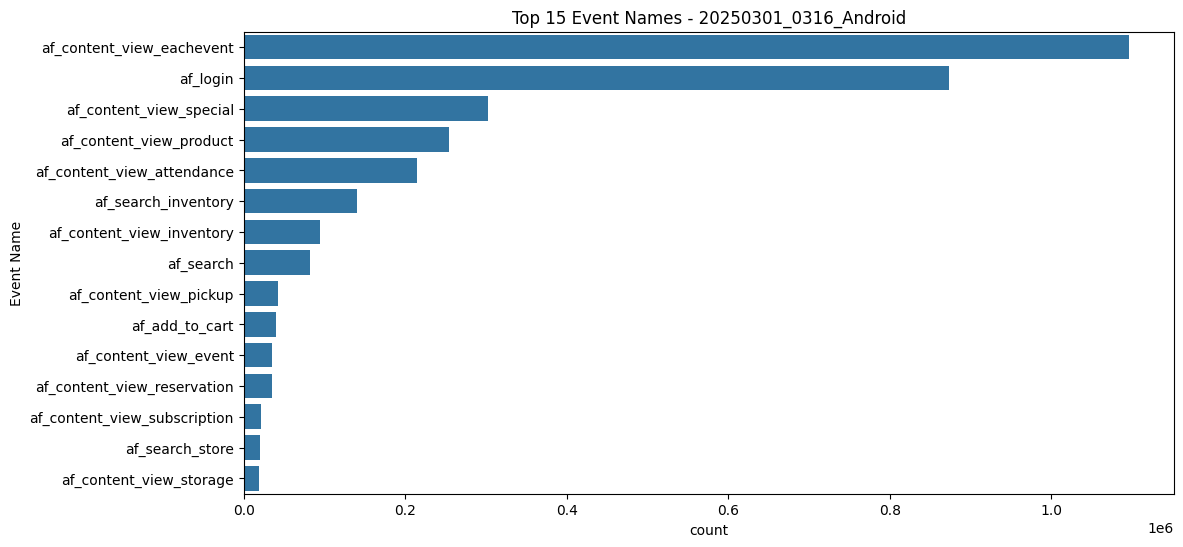

Event Time Range: None ~ None
Top 5 Media Sources:
shape: (1, 2)
┌──────────────┬─────────┐
│ Media Source ┆ count   │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ null         ┆ 3374363 │
└──────────────┴─────────┘
Columns with missing values:
                             null_count
Attributed Touch Type           3374363
Attributed Touch Time           3374363
Event Revenue                   3359778
Event Revenue KRW               3359778
Cost Model                      3374363
Cost Value                      3374363
Cost Currency                   3374363
Partner                         3374363
Media Source                    3374363
Channel                         3374363
Campaign                        3374363
Campaign ID                     3374363
Adset                           3374363
Adset ID                        3374363
Ad                              3374363
Ad ID                           3374363
Ad Type                         33743

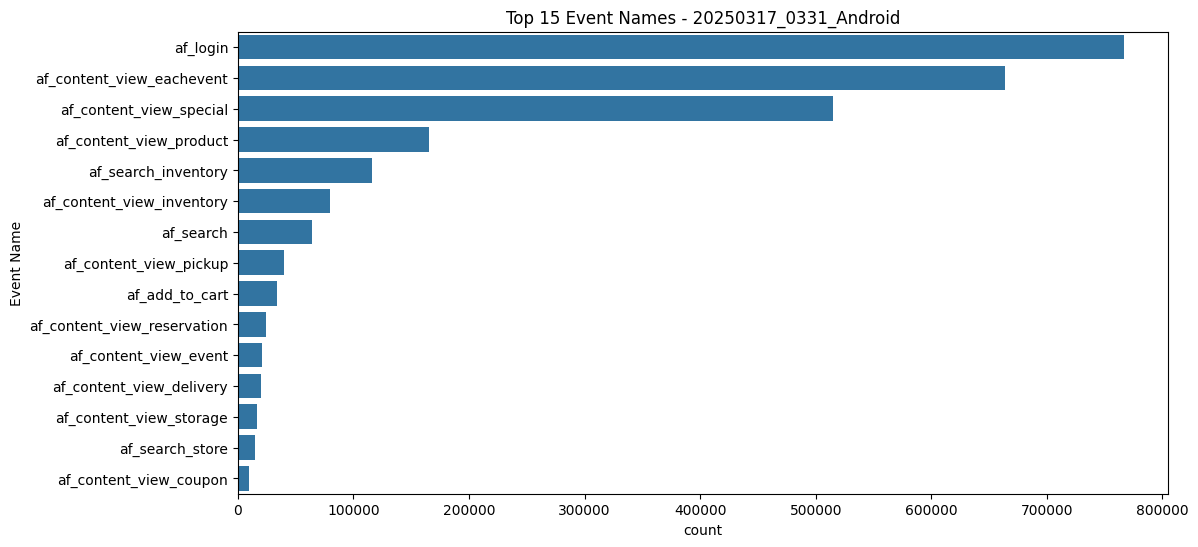

Event Time Range: None ~ None
Top 5 Media Sources:
shape: (1, 2)
┌──────────────┬─────────┐
│ Media Source ┆ count   │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ null         ┆ 2609037 │
└──────────────┴─────────┘
Columns with missing values:
                             null_count
Attributed Touch Type           2609037
Attributed Touch Time           2609037
Event Revenue                   2597013
Event Revenue KRW               2597013
Cost Model                      2609037
Cost Value                      2609037
Cost Currency                   2609037
Partner                         2609037
Media Source                    2609037
Channel                         2609037
Campaign                        2609037
Campaign ID                     2609037
Adset                           2609037
Adset ID                        2609037
Ad                              2609037
Ad ID                           2609037
Ad Type                         26090

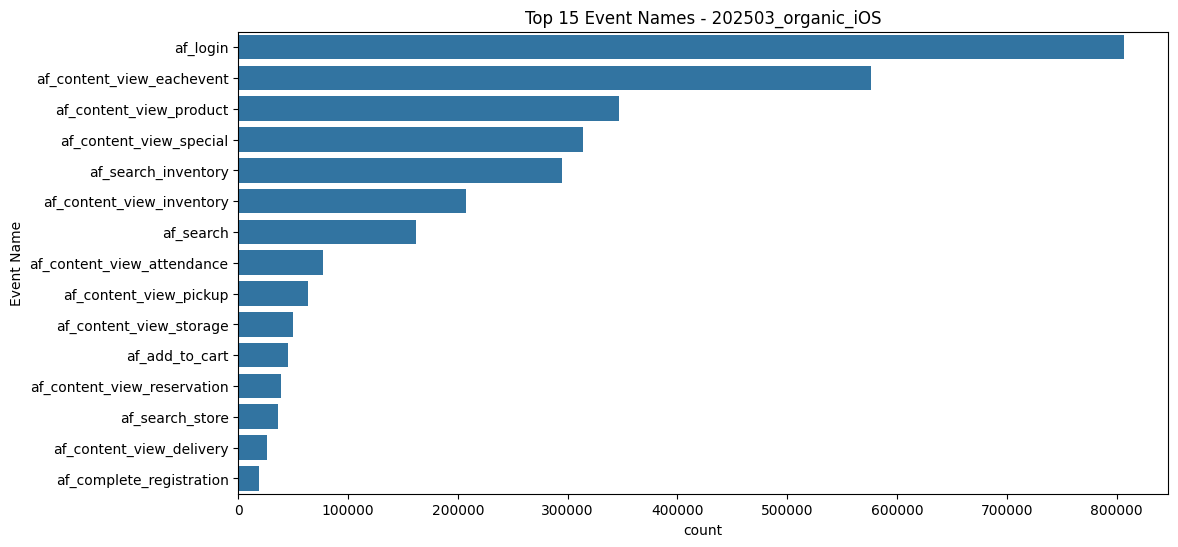

Event Time Range: None ~ None
Top 5 Media Sources:
shape: (1, 2)
┌──────────────┬─────────┐
│ Media Source ┆ count   │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ null         ┆ 3178598 │
└──────────────┴─────────┘
Columns with missing values:
                             null_count
Attributed Touch Type           3178598
Attributed Touch Time           3178598
Event Revenue                   3160550
Event Revenue KRW               3163308
Cost Model                      3178598
Cost Value                      3178598
Cost Currency                   3178598
Partner                         3178598
Media Source                    3178598
Channel                         3178598
Campaign                        3178598
Campaign ID                     3178598
Adset                           3178598
Adset ID                        3178598
Ad                              3178598
Ad ID                           3178598
Ad Type                         31785

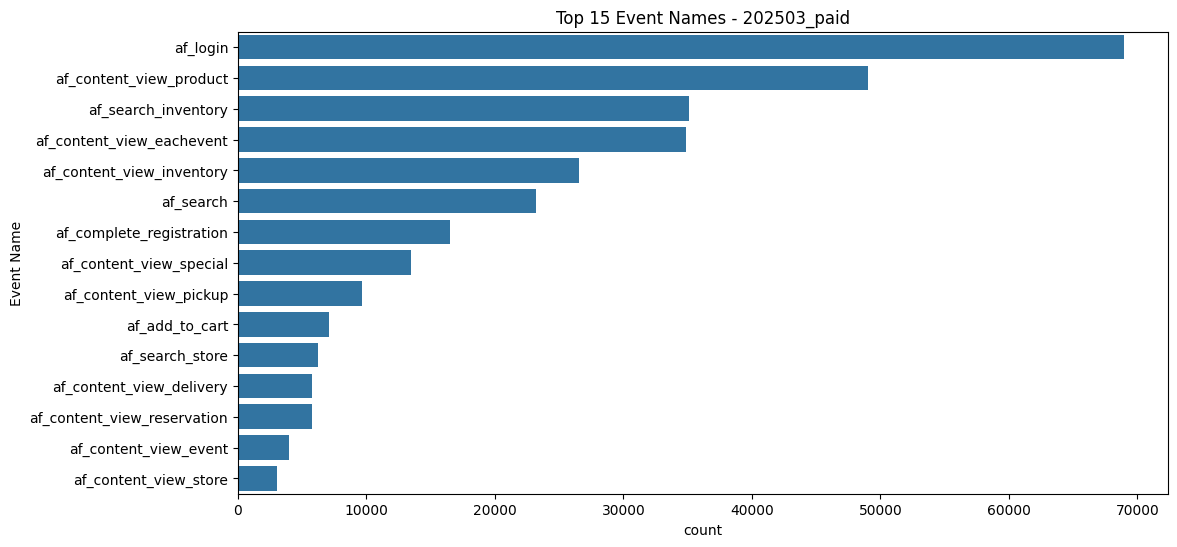

Event Time Range: None ~ None
Top 5 Media Sources:
shape: (3, 2)
┌───────────────────┬────────┐
│ Media Source      ┆ count  │
│ ---               ┆ ---    │
│ str               ┆ u32    │
╞═══════════════════╪════════╡
│ googleadwords_int ┆ 262237 │
│ nstation_int      ┆ 51032  │
│ l.point           ┆ 10225  │
└───────────────────┴────────┘
Columns with missing values:
                             null_count
Event Revenue                    320447
Event Revenue KRW                320447
Cost Model                       323494
Cost Value                       323494
Cost Currency                    323494
Partner                          323494
Channel                           51032
Campaign ID                       61257
Adset                             61257
Adset ID                          61257
Ad                               323494
Ad ID                            323494
Ad Type                           61257
Site ID                           32465
State                      

In [3]:
parquet_files = glob.glob(str(PROCESSED_DIR / "*.parquet"))

for pq_path in parquet_files:
    file_name = Path(pq_path).stem
    df = pl.read_parquet(pq_path)
    
    print(f"\n--- Analysis of {file_name} ---")
    print(f"Shape: {df.shape}")
    
    # 1. Event Name Distribution
    if "Event Name" in df.columns:
        event_counts = df["Event Name"].value_counts().sort("count", descending=True).head(15)
        
        plt.figure(figsize=(12, 6))
        sns.barplot(x="count", y="Event Name", data=event_counts.to_pandas())
        plt.title(f"Top 15 Event Names - {file_name}")
        plt.show()
    
    # 2. Time Range (if Event Time exists)
    if "Event Time" in df.columns:
        try:
            # Try to cast to datetime if not already
            event_times = df["Event Time"].cast(pl.Datetime, strict=False)
            min_time = event_times.min()
            max_time = event_times.max()
            print(f"Event Time Range: {min_time} ~ {max_time}")
        except:
            print("Could not parse Event Time as datetime.")
            
    # 3. Media Source Analysis
    if "Media Source" in df.columns:
        media_counts = df["Media Source"].value_counts().sort("count", descending=True).head(5)
        print("Top 5 Media Sources:")
        print(media_counts)
        
    # 4. Missing values check
    null_counts = df.null_count().to_pandas().T
    null_counts.columns = ['null_count']
    print("Columns with missing values:")
    print(null_counts[null_counts['null_count'] > 0])


In [4]:
df.columns

['Attributed Touch Type',
 'Attributed Touch Time',
 'Install Time',
 'Event Time',
 'Event Name',
 'Event Value',
 'Event Revenue',
 'Event Revenue Currency',
 'Event Revenue KRW',
 'Cost Model',
 'Cost Value',
 'Cost Currency',
 'Event Source',
 'Partner',
 'Media Source',
 'Channel',
 'Campaign',
 'Campaign ID',
 'Adset',
 'Adset ID',
 'Ad',
 'Ad ID',
 'Ad Type',
 'Site ID',
 'Region',
 'Country Code',
 'State',
 'DMA',
 'Operator',
 'Carrier',
 'Language',
 'AppsFlyer ID',
 'Android ID',
 'IMEI',
 'Device Category',
 'Platform',
 'OS Version',
 'App Version',
 'SDK Version',
 'App ID',
 'App Name',
 'Is Retargeting',
 'Retargeting Conversion Type',
 'Is Primary Attribution',
 'Attribution Lookback',
 'Reengagement Window',
 'Match Type',
 'User Agent',
 'HTTP Referrer',
 'Original URL',
 'Device Model',
 'Store Product Page']

In [6]:
PROCESSED_DIR = Path("../data/processed/app_event/")
parquet_files = glob.glob(str(PROCESSED_DIR / "*.parquet"))

if not parquet_files:
    print(f"경고: {PROCESSED_DIR.absolute()} 경로에 Parquet 파일이 없습니다.")
    print("먼저 CSV를 Parquet으로 변환하는 과정을 완료했는지 확인해 주세요.")
else:
    print(f"--- 앱 이벤트 데이터 기간 분석 시작 ---")
    print(f"분석 대상 파일 수: {len(parquet_files)}개\n")

    all_stats = []

    for pq_path in parquet_files:
        file_name = Path(pq_path).name
        
        try:
            # 레이지 로딩으로 데이터 스캔 (메모리 효율적)
            lf = pl.scan_parquet(pq_path)
            
            # Event Time 컬럼 존재 여부 확인
            columns = lf.collect_schema().names()
            if "Event Time" in columns:
                # 시간 데이터 처리 및 최소/최대값 계산
                # 문자열인 경우 Datetime으로 변환 시도
                date_series = df["Event Time"].str.slice(0, 10)
                valid_dates = date_series.str.to_date(strict=False)
                start = valid_dates.min()
                end = valid_dates.max()
                count = len(df)
                
                if start and end:
                    all_stats.append({"file": file_name, "start": start, "end": end, "count": count})
                    print(f"[{file_name}]")
                    print(f"  - 기간: {start} ~ {end}")
                    print(f"  - 데이터 수: {count:,} 건")
                    
                    # 3월 데이터 여부 확인
                    if start.month == 3 or end.month == 3:
                        print(f"  => [확인] 2025년 3월 데이터가 포함되어 있습니다.")
                else:
                    # 파싱 실패 시 샘플 데이터 출력하여 원인 파악
                    sample = df["Event Time"].head(3).to_list()
                    print(f"[{file_name}] 날짜 추출 실패. 샘플 데이터: {sample}")
            else:
                print(f"[{file_name}] 'Event Time' 컬럼이 없습니다.")

        except Exception as e:
            print(f"[{file_name}] 처리 중 오류: {e}")

    # 2. 전체 통합 기간 계산
    if all_stats:
        overall_start = min(s["start"] for s in all_stats)
        overall_end = max(s["end"] for s in all_stats)
        total_count = sum(s["count"] for s in all_stats)
        
        print(f"\n" + "="*60)
        print(f"전체 통합 분석 결과")
        print(f"="*60)
        print(f"최초 이벤트 발생일: {overall_start}")
        print(f"최종 이벤트 발생일: {overall_end}")
        
        duration = overall_end - overall_start
        print(f"총 데이터 기간: {duration.days}일 {duration.seconds // 3600}시간")
        print(f"총 이벤트 건수: {total_count:,} 건")
        print(f"="*60)
    else:
        print("\n분석 가능한 데이터가 없습니다.")


--- 앱 이벤트 데이터 기간 분석 시작 ---
분석 대상 파일 수: 4개

[20250301_0316_Android.parquet]
  - 기간: 2025-03-08 ~ 2025-03-31
  - 데이터 수: 323,494 건
  => [확인] 2025년 3월 데이터가 포함되어 있습니다.
[20250317_0331_Android.parquet]
  - 기간: 2025-03-08 ~ 2025-03-31
  - 데이터 수: 323,494 건
  => [확인] 2025년 3월 데이터가 포함되어 있습니다.
[202503_organic_iOS.parquet]
  - 기간: 2025-03-08 ~ 2025-03-31
  - 데이터 수: 323,494 건
  => [확인] 2025년 3월 데이터가 포함되어 있습니다.
[202503_paid.parquet]
  - 기간: 2025-03-08 ~ 2025-03-31
  - 데이터 수: 323,494 건
  => [확인] 2025년 3월 데이터가 포함되어 있습니다.

전체 통합 분석 결과
최초 이벤트 발생일: 2025-03-08
최종 이벤트 발생일: 2025-03-31
총 데이터 기간: 23일 0시간
총 이벤트 건수: 1,293,976 건


## 4. Combined Summary

Check total volume of app events.

In [ ]:
total_rows = 0
for pq_path in parquet_files:
    total_rows += pl.scan_parquet(pq_path).select(pl.len()).collect().item()

print(f"Total App Events across all files: {total_rows:,}")